# Oversampling

### Install Library

In [38]:
!pip install pandas matplotlib scikit-learn imbalanced-learn


### Load Dataset

In [37]:
import pandas as pd

# Load CSV
df = pd.read_csv("ecoli2.csv")
print()
print("="*80)
print(df.head())
print("="*80)

# Pisahkan fitur & target
X = df[["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]]
y = df["localization_class"].astype(str)

print()
print("="*60)
print("Shape fitur:", X.shape)
print("Shape target:", y.shape)
print("="*60)
print()
print("---Distribusi target:---\n")
print("="*60)
print(y.value_counts())
print("="*60)



   id protein_name   mcg   gvh   lip  chg   aac  alm1  alm2 localization_class
0   1    AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35                 cp
1   2   ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44                 cp
2   3   ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46                 cp
3   4   ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36                 cp
4   5    ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35                 cp

Shape fitur: (336, 7)
Shape target: (336,)

---Distribusi target:---

localization_class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64


### Plot Data Asli

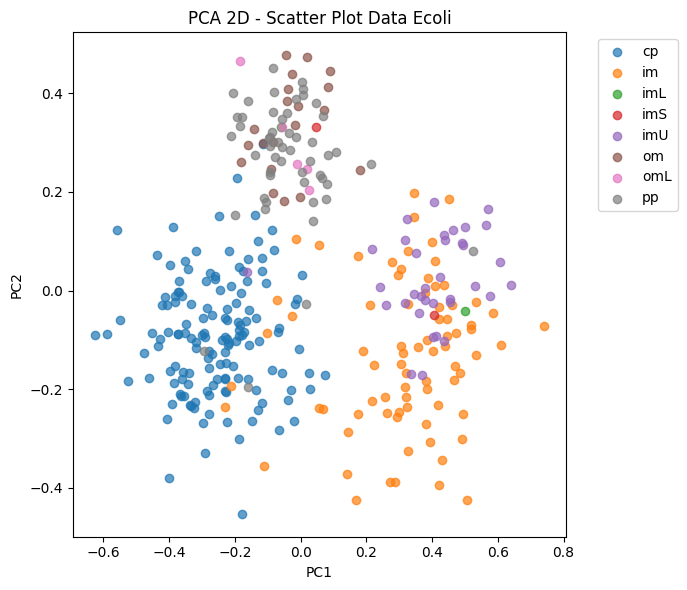

In [42]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Transform ke 2 dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot scatter
plt.figure(figsize=(7,6))
for lbl in sorted(y.unique()):
    mask = (y == lbl)
    plt.scatter(X_pca[mask,0], X_pca[mask,1], label=lbl, alpha=0.7)
plt.title("PCA 2D - Scatter Plot Data Ecoli")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


### Balancing data dengan ADASYN

In [44]:
from imblearn.over_sampling import ADASYN, SMOTE
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode target menjadi angka
le = LabelEncoder()
y_enc = le.fit_transform(y)
X_vals = X.values
y_vals = y_enc

# Tentukan n_neighbors aman untuk ADASYN
class_counts = pd.Series(y_vals).value_counts()
min_count = class_counts.min()
n_neighbors = max(1, min_count-1)

print("\n=== Info ADASYN ===")
print("Jumlah sampel per kelas sebelum balancing:\n", class_counts)
print("n_neighbors yang digunakan:", n_neighbors)

# Lakukan ADASYN, fallback ke SMOTE kalau error
try:
    adasyn = ADASYN(random_state=42, n_neighbors=n_neighbors)
    X_res, y_res = adasyn.fit_resample(X_vals, y_vals)
    method_used = f"ADASYN (n_neighbors={n_neighbors})"
    print("✅ ADASYN berhasil dijalankan")
except Exception as e:
    print("⚠ ADASYN gagal, menggunakan SMOTE sebagai fallback:", e)
    smote = SMOTE(random_state=42, k_neighbors=max(1,n_neighbors))
    X_res, y_res = smote.fit_resample(X_vals, y_vals)
    method_used = f"SMOTE (k_neighbors={max(1,n_neighbors)})"
    print("✅ SMOTE berhasil dijalankan sebagai fallback")

# Distribusi target setelah balancing
print("\nDistribusi kelas setelah balancing:\n", pd.Series(y_res).value_counts())



=== Info ADASYN ===
Jumlah sampel per kelas sebelum balancing:
 0    143
1     77
7     52
4     35
5     20
6      5
3      2
2      2
Name: count, dtype: int64
n_neighbors yang digunakan: 1
⚠ ADASYN gagal, menggunakan SMOTE sebagai fallback: Not any neigbours belong to the majority class. This case will induce a NaN case with a division by zero. ADASYN is not suited for this specific dataset. Use SMOTE instead.
✅ SMOTE berhasil dijalankan sebagai fallback

Distribusi kelas setelah balancing:
 0    143
1    143
3    143
2    143
4    143
5    143
6    143
7    143
Name: count, dtype: int64


### plot data hasil resampling + tandai titik sintetis

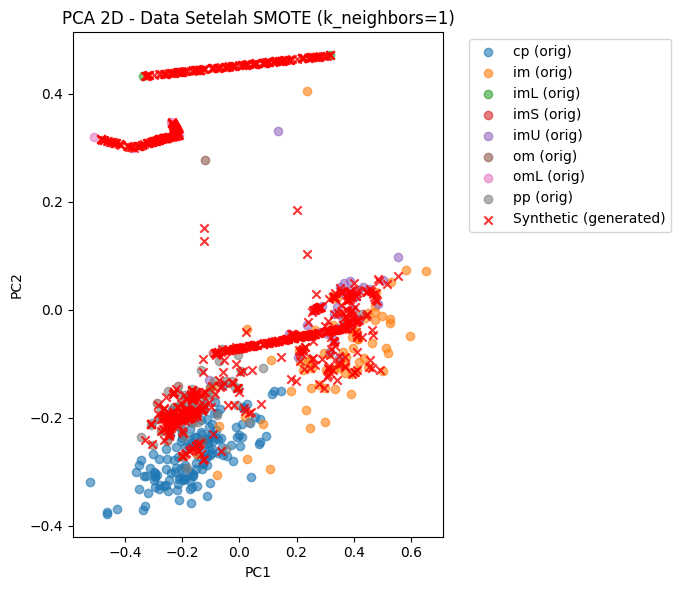

In [45]:
# PCA baru untuk data resampled
pca2 = PCA(n_components=2)
X_res_pca = pca2.fit_transform(X_res)

n_original = X_vals.shape[0]  # jumlah data asli
mask_synthetic = np.arange(X_res.shape[0]) >= n_original  # True = synthetic

# Plot
plt.figure(figsize=(7,6))
for lbl in sorted(le.classes_):
    lbl_idx = le.transform([lbl])[0]
    # Data asli
    mask_orig = (y_res == lbl_idx) & (~mask_synthetic)
    plt.scatter(X_res_pca[mask_orig,0], X_res_pca[mask_orig,1], 
                label=f"{lbl} (orig)", alpha=0.6)
# Data sintetis
plt.scatter(X_res_pca[mask_synthetic,0], X_res_pca[mask_synthetic,1], 
            marker='x', color='red', label='Synthetic (generated)', alpha=0.8)

plt.title(f"PCA 2D - Data Setelah {method_used}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()
